# Optimization Algorithms from Scratch

Six optimization algorithms — Gradient Descent, Momentum, Adam, RMSprop, a Genetic Algorithm, and
Simulated Annealing — implemented from scratch and compared on the
[Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function), a standard non-convex
benchmark with a narrow, curved valley that makes it a good stress test for optimizers. Its global
minimum is at $(1, 1)$, where $f = 0$.

$$f(x, y) = (a - x)^2 + b(y - x^2)^2, \quad a=1,\ b=100$$

In [1]:
def f(x, y, a=1, b=100):
    return (a - x) ** 2 + b * (y - x ** 2) ** 2


def numerical_gradient(x, y, h=1e-5):
    df_dx = (f(x + h, y) - f(x - h, y)) / (2 * h)
    df_dy = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return df_dx, df_dy


def analytical_gradient(x, y, a=1, b=100):
    df_dx = -2 * (a - x) - 4 * b * x * (y - x ** 2)
    df_dy = 2 * b * (y - x ** 2)
    return df_dx, df_dy


In [2]:
print(numerical_gradient(0.5, 0.5))
print(analytical_gradient(0.5, 0.5))


(-50.999999979906, 49.999999999883464)
(-51.0, 50.0)


## Gradient Descent

In [3]:
def gradient_descent(start_x, start_y, learning_rate=0.001, num_iterations=1000, a=1, b=100):
    x, y = start_x, start_y
    path = [(x, y)]

    for _ in range(num_iterations):
        df_dx, df_dy = analytical_gradient(x, y, a, b)
        x_new = x - learning_rate * df_dx
        y_new = y - learning_rate * df_dy
        x, y = x_new, y_new
        path.append((x, y))

    return path


In [4]:
path = gradient_descent(start_x=-1.0, start_y=1.0)
print(path[-1])      # should be close to (1, 1), the known minimum
print(f(*path[-1]))  # should be close to 0


(0.36363988476888187, 0.12919880558314972)
0.40587541600795535


In [5]:
path_unstable = gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.01, num_iterations=100)
print(path_unstable[-1])
print(f(*path_unstable[-1]))


(nan, nan)
nan


## Momentum

$$v \leftarrow \beta v - \eta \nabla f, \qquad x \leftarrow x + v$$

In [6]:
def momentum_gradient_descent(start_x, start_y, learning_rate=0.001, beta=0.9, num_iterations=1000, a=1, b=100):
    x, y = start_x, start_y
    v_x, v_y = 0, 0
    path = [(x, y)]

    for _ in range(num_iterations):
        df_dx, df_dy = analytical_gradient(x, y, a, b)

        v_new_x = beta * v_x - learning_rate * df_dx
        x_new = x + v_new_x

        v_new_y = beta * v_y - learning_rate * df_dy
        y_new = y + v_new_y

        x, y = x_new, y_new
        v_x, v_y = v_new_x, v_new_y

        path.append((x, y))

    return path


In [7]:
path_momentum = momentum_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.001, num_iterations=1000)
print(path_momentum[-1])
print(f(*path_momentum[-1]))


(0.9938860026510479, 0.9877848291178886)
3.7441268933752366e-05


In [8]:
for beta_test in [0.0, 0.3, 0.5, 0.9, 0.99]:
    path_test = momentum_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.001, beta=beta_test, num_iterations=1000)
    print(f"beta={beta_test}: final point={path_test[-1]}, f={f(*path_test[-1]):.6f}")


beta=0.0: final point=(0.36363988476888187, 0.12919880558314972), f=0.405875
beta=0.3: final point=(0.5892585905521133, 0.3451947579955958), f=0.169121
beta=0.5: final point=(0.7283505078272502, 0.5292251927709407), f=0.073955
beta=0.9: final point=(0.9938860026510479, 0.9877848291178886), f=0.000037
beta=0.99: final point=(0.9858072806182137, 0.9721094207319058), f=0.000210


## Adam

$$m \leftarrow \beta_1 m + (1-\beta_1)\nabla f, \qquad v \leftarrow \beta_2 v + (1-\beta_2)\nabla f^2$$
$$\hat{m} = \frac{m}{1-\beta_1^t}, \qquad \hat{v} = \frac{v}{1-\beta_2^t}, \qquad x \leftarrow x - \eta \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

In [9]:
def adam_gradient_descent(start_x, start_y, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, num_iterations=1000, a=1, b=100):
    x, y = start_x, start_y
    m_x, m_y = 0, 0
    v_x, v_y = 0, 0
    path = [(x, y)]

    for t in range(1, num_iterations + 1):
        df_dx, df_dy = analytical_gradient(x, y, a, b)

        m_new_x = beta1 * m_x + (1 - beta1) * df_dx
        m_new_y = beta1 * m_y + (1 - beta1) * df_dy

        v_new_x = beta2 * v_x + (1 - beta2) * (df_dx ** 2)
        v_new_y = beta2 * v_y + (1 - beta2) * (df_dy ** 2)

        m_hat_x = m_new_x / (1 - beta1 ** t)
        m_hat_y = m_new_y / (1 - beta1 ** t)

        v_hat_x = v_new_x / (1 - beta2 ** t)
        v_hat_y = v_new_y / (1 - beta2 ** t)

        x_new = x - learning_rate * m_hat_x / (v_hat_x ** (1 / 2) + epsilon)
        y_new = y - learning_rate * m_hat_y / (v_hat_y ** (1 / 2) + epsilon)

        x, y = x_new, y_new
        m_x, m_y = m_new_x, m_new_y
        v_x, v_y = v_new_x, v_new_y

        path.append((x, y))

    return path


In [10]:
path_adam = adam_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.05, num_iterations=1000)
print(path_adam[-1])
print(f(*path_adam[-1]))


(0.9999968994338848, 0.9999937883516508)
9.624589338903288e-12


## The Genetic Algorithm

In [11]:
import numpy as np


In [12]:
def initialize_population(population_size, low=-2, high=2):
    population = np.random.uniform(low, high, size=(population_size, 2))
    return population


In [13]:
pop = initialize_population(20)
print(pop.shape)  # expect (20, 2)
print(pop[:3])     # peek at first 3 candidates


(20, 2)
[[-1.64820209 -1.2144887 ]
 [-0.2556918   1.78972385]
 [ 1.04039048 -0.24598422]]


In [14]:
def evaluate_population(population, a=1, b=100):
    x = population[:, 0]
    y = population[:, 1]
    fitness = f(x, y, a, b)
    return fitness


In [15]:
fitness = evaluate_population(pop)
print(fitness.shape)  # expect (20,)
print(fitness[:5])    # peek at first 5 fitness values


(20,)
[1552.335325    298.91351969  176.4653782   569.26007533   99.42923151]


### Tournament Selection

Pick a small random group (e.g. 3 individuals) from the population, and the one with the best (lowest)
fitness among that group wins and becomes a parent. Repeat this process to select as many parents as
needed.

In [16]:
def tournament_selection(population, fitness, tournament_size=3):
    indices = np.random.choice(len(population), size=tournament_size, replace=False)
    tournament_fitness = fitness[indices]
    winner_index = indices[np.argmin(tournament_fitness)]
    return population[winner_index]


In [17]:
winner = tournament_selection(pop, fitness)
print(winner)


[-0.86792054  1.73277626]


In [18]:
def crossover(parent1, parent2):
    alpha = np.random.uniform(0, 1)
    child = alpha * parent1 + (1 - alpha) * parent2
    return child


In [19]:
p1 = np.array([1.0, 1.0])
p2 = np.array([-1.0, 0.5])
child = crossover(p1, p2)
print(child)


[0.61945746 0.90486436]


In [20]:
def mutate(individual, mutation_rate=0.1, mutation_strength=0.1):
    if np.random.random() < mutation_rate:
        noise = np.random.normal(0, mutation_strength, size=individual.shape)
        individual = individual + noise
    return individual


In [21]:
individual = np.array([0.5, 0.5])
mutated_results = [mutate(individual.copy()) for _ in range(20)]
for m in mutated_results:
    print(m)


[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]
[0.59217554 0.39531013]
[0.5 0.5]
[0.5 0.5]
[0.5 0.5]


In [22]:
def genetic_algorithm(population_size=50, num_generations=200, a=1, b=100):
    population = initialize_population(population_size)
    best_history = []

    for gen in range(num_generations):
        fitness = evaluate_population(population, a, b)

        best_idx = np.argmin(fitness)
        best_history.append((population[best_idx].copy(), fitness[best_idx]))

        new_population = []
        for _ in range(population_size):
            parent1 = tournament_selection(population, fitness)
            parent2 = tournament_selection(population, fitness)
            child = crossover(parent1, parent2)
            child = mutate(child)
            new_population.append(child)

        population = np.array(new_population)

    return population, best_history


In [23]:
final_pop, history = genetic_algorithm(population_size=50, num_generations=200)
best_point, best_fitness = history[-1]
print(best_point, best_fitness)


[1.01635564 1.03415262] 0.00040529410499735743


## RMSprop

$$v \leftarrow \beta v + (1-\beta)\nabla f^2, \qquad x \leftarrow x - \eta \frac{\nabla f}{\sqrt{v} + \epsilon}$$

In [24]:
def rmsprop_gradient_descent(start_x, start_y, learning_rate=0.001, beta=0.9, epsilon=1e-8, num_iterations=1000, a=1, b=100):
    x, y = start_x, start_y
    v_x, v_y = 0, 0
    path = [(x, y)]

    for _ in range(num_iterations):
        df_dx, df_dy = analytical_gradient(x, y, a, b)

        v_new_x = beta * v_x + (1 - beta) * (df_dx ** 2)
        v_new_y = beta * v_y + (1 - beta) * (df_dy ** 2)

        x_new = x - learning_rate * df_dx / (v_new_x ** (1 / 2) + epsilon)
        y_new = y - learning_rate * df_dy / (v_new_y ** (1 / 2) + epsilon)

        x, y = x_new, y_new
        v_x, v_y = v_new_x, v_new_y

        path.append((x, y))

    return path


In [25]:
path_rmsprop_small = rmsprop_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.001, num_iterations=1000)
print("small lr:", path_rmsprop_small[-1], f(*path_rmsprop_small[-1]))

path_rmsprop_scaled = rmsprop_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.05, num_iterations=1000)
print("scaled lr:", path_rmsprop_scaled[-1], f(*path_rmsprop_scaled[-1]))

path_rmsprop_tuned = rmsprop_gradient_descent(start_x=-1.0, start_y=1.0, learning_rate=0.01, num_iterations=1000)
print("tuned lr:", path_rmsprop_tuned[-1], f(*path_rmsprop_tuned[-1]))


small lr: (-0.19625781020702662, 0.03857996590422034) 1.4310331433406862
scaled lr: (0.7108893187584725, 0.44595973006769146) 0.43646724179530233
tuned lr: (0.8819318677445084, 0.7636132820771242) 0.034077218644620905


## Simulated Annealing

A gradient-free method that takes random steps, always accepting improving moves and sometimes
accepting worsening ones (to escape local minima), with the acceptance probability shrinking as the
"temperature" cools:

```
if new_f < current_f:
    accept always
else:
    accept with probability = exp(-(new_f - current_f) / temperature)
```

In [26]:
def accept_move(current_f, new_f, temperature):
    if new_f < current_f:
        return True
    else:
        probability = np.exp(-(new_f - current_f) / temperature)
        return np.random.random() < probability


In [27]:
def simulated_annealing(start_x, start_y, initial_temp=10, cooling_rate=0.995, step_size=0.1, num_iterations=1000, a=1, b=100):
    x, y = start_x, start_y
    current_f = f(x, y, a, b)
    temperature = initial_temp
    path = [(x, y)]

    for _ in range(num_iterations):
        new_x = x + np.random.normal(0, step_size)
        new_y = y + np.random.normal(0, step_size)
        new_f = f(new_x, new_y, a, b)

        if accept_move(current_f, new_f, temperature):
            x, y = new_x, new_y
            current_f = new_f

        temperature *= cooling_rate
        path.append((x, y))

    return path


In [28]:
sa_results = []
for _ in range(20):
    path_sa = simulated_annealing(start_x=-1.0, start_y=1.0, num_iterations=1000)
    sa_results.append(f(*path_sa[-1]))

sa_results = np.array(sa_results)
print(f"mean: {sa_results.mean():.4f}, best: {sa_results.min():.4f}, worst: {sa_results.max():.4f}")


mean: 0.6586, best: 0.0028, worst: 4.6769


## Comparison

In [29]:
def path_to_losses(path, a=1, b=100):
    losses = [f(x, y, a, b) for x, y in path]
    return losses


In [30]:
loss_path = path_to_losses(path)
print(loss_path[:3])
print(loss_path[-3:])


[4.0, 3.9903904256, 3.987182292617209]
[0.4080054805105675, 0.4069382065097675, 0.40587541600795535]


In [31]:
start_x, start_y = -1.0, 1.0
num_iter = 1000

results = {
    "Gradient Descent": gradient_descent(start_x, start_y, learning_rate=0.001, num_iterations=num_iter),
    "Momentum": momentum_gradient_descent(start_x, start_y, learning_rate=0.001, num_iterations=num_iter),
    "Adam": adam_gradient_descent(start_x, start_y, learning_rate=0.05, num_iterations=num_iter),
    "RMSprop": rmsprop_gradient_descent(start_x, start_y, learning_rate=0.01, num_iterations=num_iter),
}


In [32]:
_, ga_history = genetic_algorithm(population_size=50, num_generations=200)
ga_losses = [fitness for point, fitness in ga_history]

path_sa = simulated_annealing(start_x, start_y, num_iterations=1000)
sa_losses = path_to_losses(path_sa)


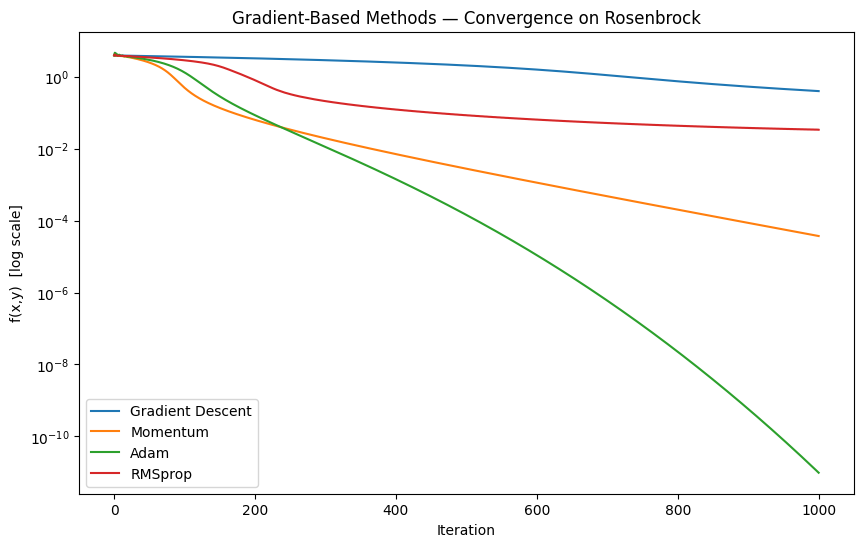

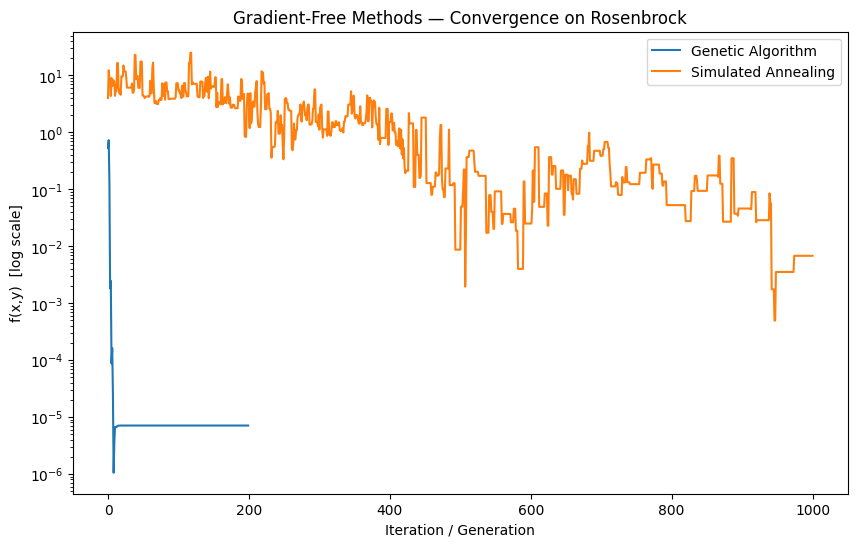

In [33]:
import matplotlib.pyplot as plt

# Figure 1: gradient-based methods
plt.figure(figsize=(10, 6))
for name, path in results.items():
    losses = path_to_losses(path)
    plt.plot(losses, label=name)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("f(x,y)  [log scale]")
plt.title("Gradient-Based Methods — Convergence on Rosenbrock")
plt.legend()
plt.show()

# Figure 2: gradient-free methods
plt.figure(figsize=(10, 6))
plt.plot(ga_losses, label="Genetic Algorithm")
plt.plot(sa_losses, label="Simulated Annealing")
plt.yscale("log")
plt.xlabel("Iteration / Generation")
plt.ylabel("f(x,y)  [log scale]")
plt.title("Gradient-Free Methods — Convergence on Rosenbrock")
plt.legend()
plt.show()


In [34]:
x_range = np.linspace(-2, 2, 200)
y_range = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)


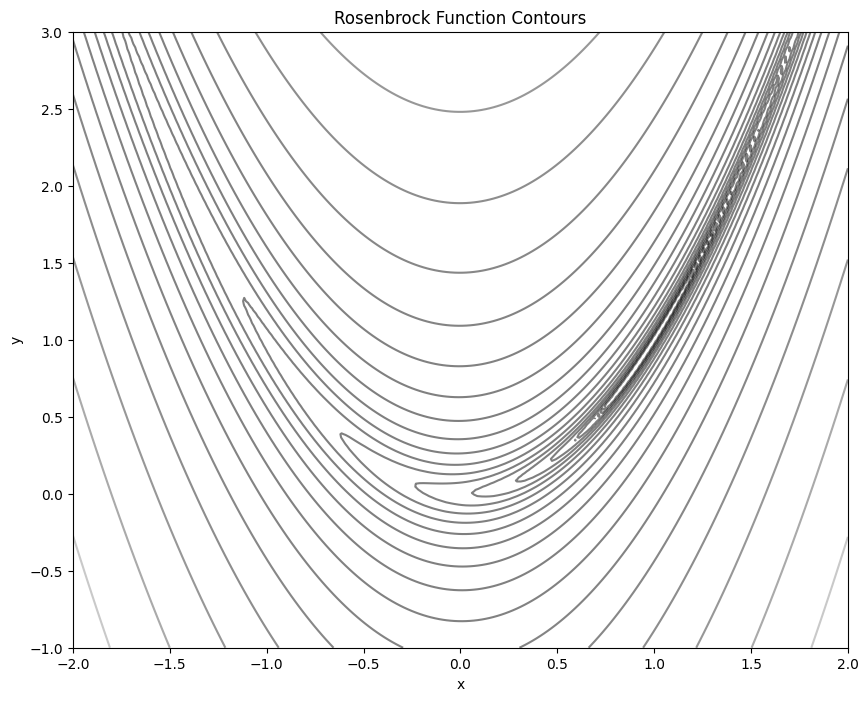

In [35]:
plt.figure(figsize=(10, 8))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap="gray", alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Rosenbrock Function Contours")
plt.show()


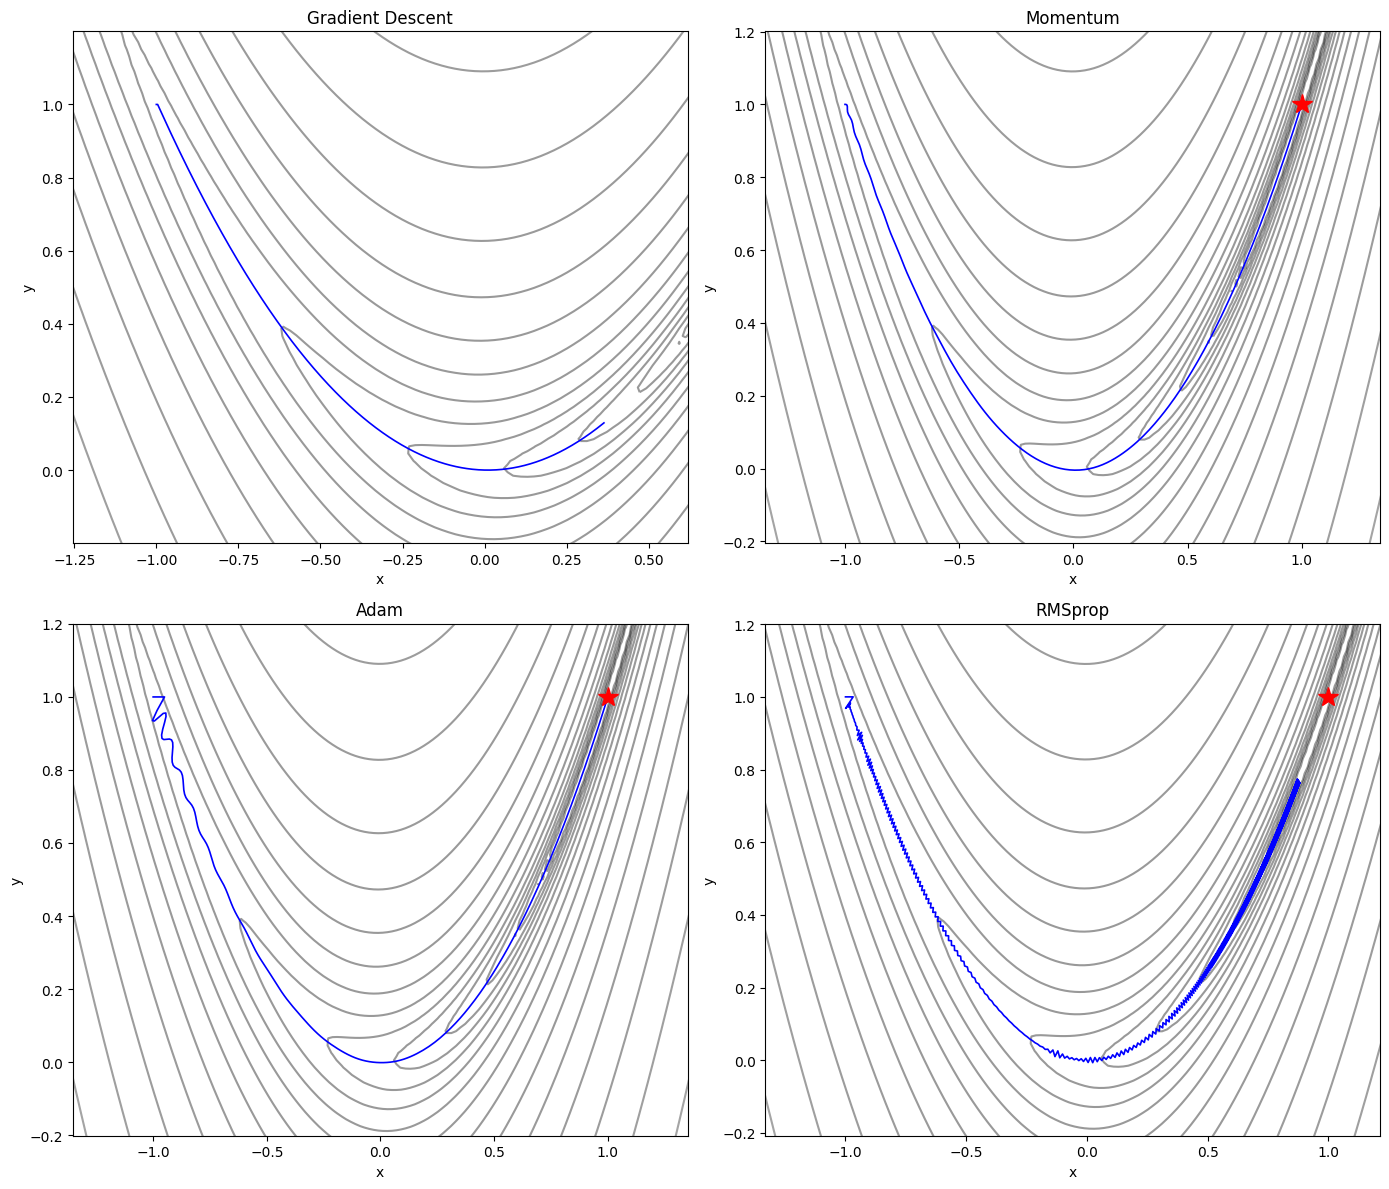

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, path) in zip(axes, results.items()):
    ax.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 20), cmap="gray", alpha=0.4)

    xs = [p[0] for p in path]
    ys = [p[1] for p in path]
    ax.plot(xs, ys, color="blue", linewidth=1.2)
    ax.plot(1, 1, marker="*", color="red", markersize=15)

    # zoom tightly around this path's own range, with a little padding
    pad_x = (max(xs) - min(xs)) * 0.15 + 0.05
    pad_y = (max(ys) - min(ys)) * 0.15 + 0.05
    ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
    ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)

    ax.set_title(name)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()


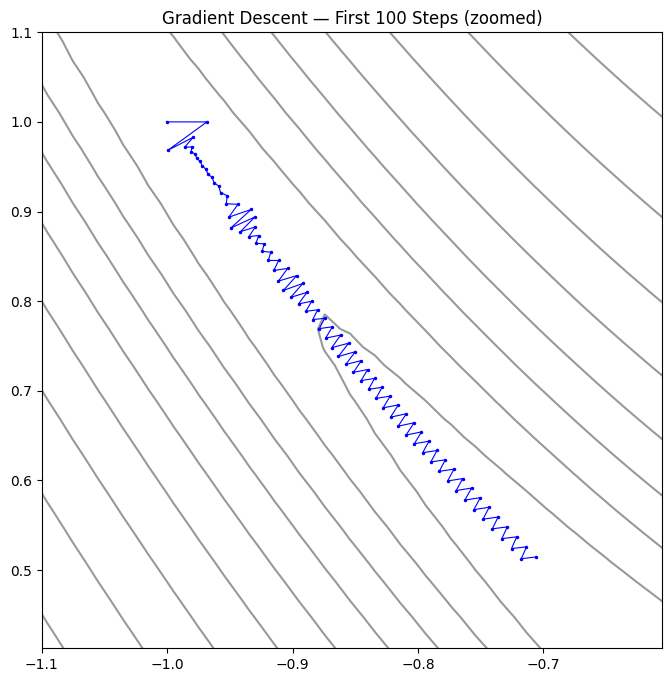

In [37]:
path_gd_zoom = path[:100]  # just the first 100 steps
xs = [p[0] for p in path_gd_zoom]
ys = [p[1] for p in path_gd_zoom]

plt.figure(figsize=(8, 8))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3.5, 30), cmap="gray", alpha=0.4)
plt.plot(xs, ys, color="blue", marker=".", markersize=3, linewidth=0.8)
plt.xlim(min(xs) - 0.1, max(xs) + 0.1)
plt.ylim(min(ys) - 0.1, max(ys) + 0.1)
plt.title("Gradient Descent — First 100 Steps (zoomed)")
plt.show()
